**Problem Tanımı:** Cifar10 veriseti içerisindeki 10 farklı sınıfın sınıflandırılması

**Sınıflar:** kedi, kurbağa, uçak, araba ...

**Kullanılacak Deep Learning Algoritması:** CNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10 # our dataset
from tensorflow.keras.utils import to_categorical # to apply one-hot encoding
from tensorflow.keras.models import Sequential # for modelling
from tensorflow.keras.layers import Conv2D, MaxPooling2D # feature extraction
from tensorflow.keras.layers import Dense, Flatten, Dropout # classification
from tensorflow.keras.optimizers import RMSprop # optimizer algorithm like Adam or Gradient descent
from tensorflow.keras.preprocessing.image import ImageDataGenerator # for data augmentation

from sklearn.metrics import classification_report # for evaluating our results

2025-11-01 18:45:30.558877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762022730.883778      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762022730.974765      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import numpy as np
import os
import pickle
from tensorflow.keras.datasets import cifar10 # Sadece kontrol için gerekli, load_data kullanılmayacak

# 1. Yardımcı Fonksiyon: Pickle dosyasını açar
def unpickle(file):
    with open(file, 'rb') as fo:
        # Kodun eski Python versiyonlarıyla uyumlu olması için encoding='bytes' kullanıyoruz
        dict = pickle.load(fo, encoding='bytes') 
    return dict

# 2. Ana Yükleme Fonksiyonu
def load_cifar10_manually(data_dir):
    x_train_batches, y_train_batches = [], []
    
    # Tüm 5 eğitim dosyasını yükle
    for i in range(1, 6):
        file_path = os.path.join(data_dir, f'data_batch_{i}')
        data_dict = unpickle(file_path)
        x_train_batches.append(data_dict[b'data'])
        y_train_batches.append(data_dict[b'labels'])

    # Eğitim verilerini birleştir ve NumPy dizisine çevir
    x_train = np.concatenate(x_train_batches)
    y_train = np.concatenate(y_train_batches).reshape(-1, 1)

    # Test dosyasını yükle
    test_file_path = os.path.join(data_dir, 'test_batch')
    test_dict = unpickle(test_file_path)
    x_test = test_dict[b'data']
    y_test = np.array(test_dict[b'labels']).reshape(-1, 1)

    # Görüntüleri yeniden şekillendir: (N, 3072) -> (N, 32, 32, 3)
    # CIFAR-10 verisi (Kanal, Yükseklik, Genişlik) formatında depolanmıştır, transpose ile (Yükseklik, Genişlik, Kanal) formatına çevrilir.
    x_train = x_train.reshape((len(x_train), 3, 32, 32)).transpose(0, 2, 3, 1)
    x_test = x_test.reshape((len(x_test), 3, 32, 32)).transpose(0, 2, 3, 1)

    return (x_train, y_train), (x_test, y_test)

# 3. Çalıştırma
DATA_DIR = '/kaggle/input/cifar10/' # Sizin görselinize göre doğru yol

(x_train, y_train), (x_test, y_test) = load_cifar10_manually(DATA_DIR)

# Kontrol
print(f"Eğitim Verisi Şekli: {x_train.shape}")
print(f"Eğitim Etiketleri Şekli: {y_train.shape}")
print(f"Test Verisi Şekli: {x_test.shape}")
print(f"Test Etiketleri Şekli: {y_test.shape}")

Eğitim Verisi Şekli: (50000, 32, 32, 3)
Eğitim Etiketleri Şekli: (50000, 1)
Test Verisi Şekli: (10000, 32, 32, 3)
Test Etiketleri Şekli: (10000, 1)


/tmp/ipykernel_13/954036928.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = class_labels[int(y_train[i])]


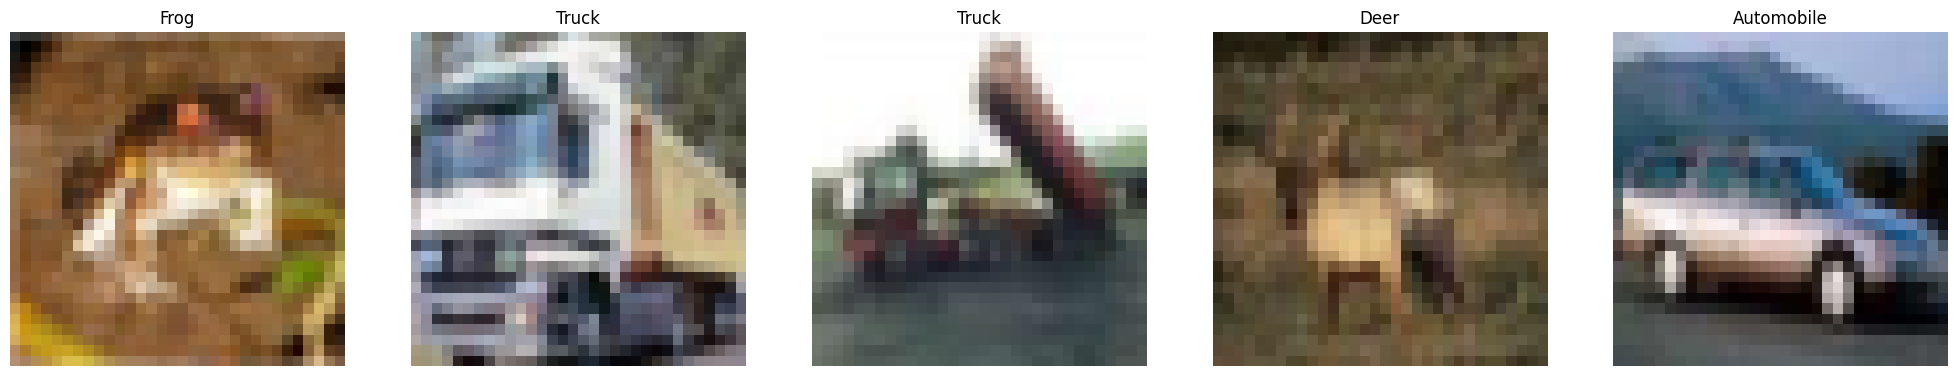

In [3]:
# verisetindeki ilk 5 değeri görselleştirme

class_labels = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]

fig, axes = plt.subplots(1, 5, figsize=(25, 20)) # boyutu 25'e 20 olan, 1 satır ve 5 sütundan oluşan bir tane plot oluştur

for i in range(5):
    axes[i].imshow(x_train[i])
    label = class_labels[int(y_train[i])]
    axes[i].set_title(label)
    axes[i].axis("off")

In [4]:
 # normalization

x_train = (x_train).astype("float32")/255
x_test = (x_test).astype("float32")/255

# Bağımsız değişkenleri 0-1 arasına eşitlemek için 255'e bölüyoruz, çünkü resimler 0 ile 255 arasında piksel değerlerine sahip

In [5]:
# one-hot encoding

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test, 10)

In [6]:
# data augmentation

datagen = ImageDataGenerator(
    rotation_range = 20,      # resmi 20 derece döndürme
    width_shift_range = 0.2,  # resmi yatayda %20 kaydırma
    height_shift_range = 0.2, # resmi dikeyde %20 kaydırma
    shear_range = 0.2,        # resmi %20 rastgele açıyla eğme/yamultma
    zoom_range = 0.2,         # resmi %20 yaklaştırma
    horizontal_flip = True,   # resmi yatayda ters çevir
)

datagen.fit(x_train)

In [7]:
# create model 

model = Sequential()

# feature extraction
model.add(Conv2D(32, (3,3), padding="same", activation="relu", input_shape=x_train.shape[1:])) # convolution katmanı
model.add(MaxPooling2D(pool_size=(2,2))) # pooling katmanı
model.add(Conv2D(32, (3,3), activation="relu")) # tekrardan convolution katmanı
model.add(Dropout(0.25)) # dropout katmanı

# tekrardan aynı yapı
model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, (3,3), activation="relu"))
model.add(Dropout(0.25))


# classification
model.add(Flatten()) # flatten katmanı - işlemlere başlamadan önce
model.add(Dense(512, activation="relu")) # normal neural network kısmı
model.add(Dropout(0.50)) # dropout layer
model.add(Dense(10, activation="softmax")) # output layer - çıktı 10 tane olduğundan 10

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-01 18:45:57.164933: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,410 (3.40 MB)

 Trainable params: 890,410 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# model compile

model.compile(optimizer=RMSprop(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

In [9]:
# model training

history = model.fit(datagen.flow(x_train, y_train, batch_size=512), epochs=10, validation_data=(x_test, y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 72s 702ms/step - accuracy: 0.1199 - loss: 2.2799 - val_accuracy: 0.2395 - val_loss: 2.1009
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 679ms/step - accuracy: 0.2155 - loss: 2.0868 - val_accuracy: 0.2391 - val_loss: 2.0941
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 670ms/step - accuracy: 0.2426 - loss: 2.0364 - val_accuracy: 0.3159 - val_loss: 1.9487
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 714ms/step - accuracy: 0.2770 - loss: 1.9699 - val_accuracy: 0.3549 - val_loss: 1.8502
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 68s 691ms/step - accuracy: 0.2963 - loss: 1.9252 - val_accuracy: 0.3264 - val_loss: 1.9022
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 681ms/step - accuracy: 0.3064 - loss: 1.8983 - val_accuracy: 0.3716 - val_loss: 1.7734
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 708ms/step - accuracy: 0.3164 - loss: 1.8626 - val_accuracy: 0.3735 - val_loss: 1.7648
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 678ms/step - accuracy: 0.3295 - loss: 1.8309 - val_accu

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
              precision    recall  f1-score   support

    Airplane       0.64      0.30      0.41      1000
  Automobile       0.60      0.46      0.52      1000
        Bird       0.23      0.15      0.19      1000
         Cat       0.25      0.06      0.10      1000
        Deer       0.33      0.43      0.37      1000
         Dog       0.41      0.35      0.38      1000
        Frog       0.29      0.72      0.41      1000
       Horse       0.37      0.50      0.43      1000
        Ship       0.55      0.45      0.50      1000
       Truck       0.47      0.47      0.47      1000

    accuracy                           0.39     10000
   macro avg       0.41      0.39      0.38     10000
weighted avg       0.41      0.39      0.38     10000



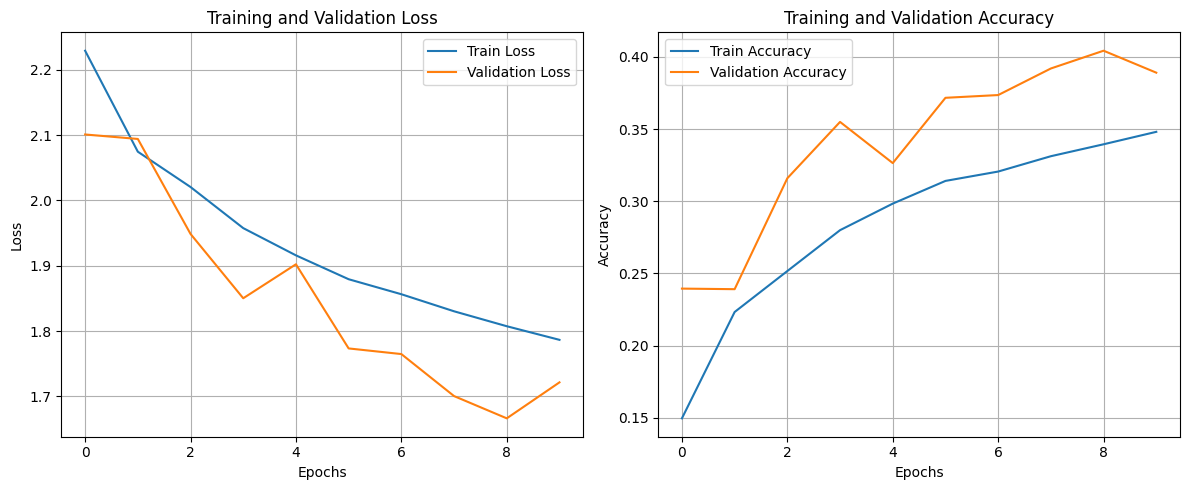

In [10]:
# modelin test seti üzerinden tahminini yap
y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) # gerçek sınıfları al (One-Hot'tan normal etikete çevir)

# classification report hesapla
report = classification_report(y_true, y_pred_class, target_names=class_labels)
print(report)

# kayıp grafikleri
plt.figure(figsize=(12, 5)) # figür boyutunu eklemek iyi olur

plt.subplot(1, 2, 1) # 1 satır, 2 sütun ve 1. subplot
plt.plot(history.history["loss"], label = "Train Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

# accuracy grafikleri
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label = "Train Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()